# 03 — Multiclass Modeling (SMOTE) on IndoBERT Embeddings

This notebook focuses on 3-class sentiment classification:
- **Labels:** Positif (0), Negatif (1), Netral (2)
- **Challenge:** Extreme class imbalance (Netral ~12, Negatif ~49, Positif ~1495)
- **Strategy:** 
  1. Extract embeddings using `indobenchmark/indobert-base-p1`.
  2. Apply **SMOTE** (Synthetic Minority Over-sampling Technique) to balance the feature vectors.
  3. Train a lightweight classifier (MLP or Logistic Regression) on balanced embeddings.

In [21]:
## 0. Google Colab Setup (Run this if using Google Colab)
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Google Colab detected — mounting Drive & installing packages …")
    from google.colab import drive
    drive.mount("/content/drive")

    # --- ADJUST THIS PATH to your folder in Google Drive ---
    DRIVE_PROJECT = "/content/drive/MyDrive/xai_lime_vs_shap"

    if os.path.isdir(DRIVE_PROJECT):
        os.chdir(DRIVE_PROJECT)
        print(f"CWD set to: {DRIVE_PROJECT}")
    else:
        print(f"WARNING: '{DRIVE_PROJECT}' not found. Please check your Drive path.")

    # Install required packages for Colab
    !pip install -q transformers imbalanced-learn datasets accelerate
else:
    print("Local environment detected — skipping Colab setup.")

Google Colab detected — mounting Drive & installing packages …
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD set to: /content/drive/MyDrive/xai_lime_vs_shap


In [22]:
## 1. Imports & Config
import os, sys, warnings, json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

def find_project_root() -> Path:
    markers = ["data", "notebooks", "src"]
    candidate = Path.cwd()
    for _ in range(3):
        if all((candidate / m).exists() for m in markers):
            return candidate
        candidate = candidate.parent
    return Path.cwd()

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tokopedia_reviews_clean.csv"
MODEL_SAVE_DIR = PROJECT_ROOT / "outputs" / "indobert_smote"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "indobenchmark/indobert-base-p1"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data Path   : {DATA_PATH}")
print(f"Device      : {DEVICE}")

Project root: /content/drive/MyDrive/xai_lime_vs_shap
Data Path   : /content/drive/MyDrive/xai_lime_vs_shap/data/processed/tokopedia_reviews_clean.csv
Device      : cuda


In [23]:
## 2. Load & Prepare Data
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Check your Google Drive mounting or path.")

df = pd.read_csv(DATA_PATH)
LABEL_MAP = {"Positif": 0, "Negatif": 1, "Netral": 2}
ID2LABEL = {0: "Positif", 1: "Negatif", 2: "Netral"}

df['label'] = df['sentiment_label'].map(LABEL_MAP)
df = df.dropna(subset=['review_text_clean', 'label'])

print("Initial Distribution:")
print(df['sentiment_label'].value_counts())

# Split before extracting embeddings to prevent leak
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['review_text_clean'].values, 
    df['label'].values, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=df['label'].values
)

print(f"\nTrain size: {len(X_train_raw)}")
print(f"Test size: {len(X_test_raw)}")

Initial Distribution:
sentiment_label
Positif    1418
Negatif      79
Netral       62
Name: count, dtype: int64

Train size: 1247
Test size: 312


In [25]:
## 3. IndoBERT Embedding Extraction Function

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
bert_model.eval()

def get_embeddings(texts, batch_size=16):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(
            list(batch), 
            padding=True, 
            truncation=True, 
            max_length=128, 
            return_tensors="pt"
        ).to(DEVICE)
        
        with torch.no_grad():
            # Use [CLS] token (index 0) as sentence representation
            outputs = bert_model(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_emb)
            
    return np.vstack(embeddings)

print("Extracting training embeddings...")
X_train_emb = get_embeddings(X_train_raw)

print("Extracting testing embeddings...")
X_test_emb = get_embeddings(X_test_raw)

print(f"Embedding shape: {X_train_emb.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Extracting training embeddings...
Extracting testing embeddings...
Embedding shape: (1247, 768)


In [26]:
## 4. Balancing with SMOTE

# SMOTE k_neighbors must be < than minority class size
# Train set Neutral is ~10 (80% of 12). Default k=5.
sm = SMOTE(k_neighbors=5, random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train_emb, y_train)

print("Distribution after SMOTE:")
resampled_counts = pd.Series(y_train_res).value_counts().rename(index=ID2LABEL)
print(resampled_counts)

Distribution after SMOTE:
Positif    1134
Netral     1134
Negatif    1134
Name: count, dtype: int64


In [28]:
## 5. MLP Classifier Training (PyTorch)

class MLP(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_dim)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(0.2)
        self.fc2 = torch.nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

input_dim = X_train_res.shape[1]
hidden_dim = 256
output_dim = 3

classifier = MLP(input_dim, hidden_dim, output_dim).to(DEVICE)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-3, weight_decay=0.01)

# Convert to tensors & batches
X_train_t = torch.tensor(X_train_res, dtype=torch.float32)
y_train_t = torch.tensor(y_train_res, dtype=torch.long)
train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

print("Training classifier...")
for epoch in range(20):
    classifier.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        outputs = classifier(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/20 - Loss: {total_loss/len(train_loader):.4f}")

Training classifier...
Epoch 5/20 - Loss: 0.0328
Epoch 10/20 - Loss: 0.0078
Epoch 15/20 - Loss: 0.0021
Epoch 20/20 - Loss: 0.0009



Classification Report:
              precision    recall  f1-score   support

     Positif       0.95      0.98      0.97       284
     Negatif       0.62      0.50      0.55        16
      Netral       0.67      0.33      0.44        12

    accuracy                           0.93       312
   macro avg       0.74      0.61      0.65       312
weighted avg       0.92      0.93      0.93       312



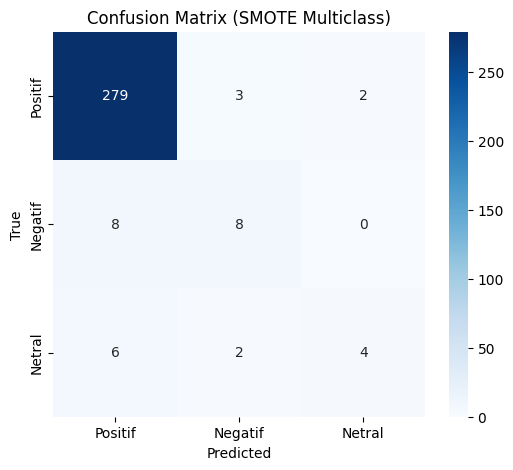

In [29]:
## 6. Evaluation

classifier.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test_emb, dtype=torch.float32).to(DEVICE)
    logits = classifier(X_test_t)
    preds = torch.argmax(logits, dim=1).cpu().numpy()

target_names = ["Positif", "Negatif", "Netral"]
print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=target_names))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix (SMOTE Multiclass)")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.show()

In [31]:
## 7. Save Model & Assets

# Save MLP weights
torch.save(classifier.state_dict(), MODEL_SAVE_DIR / "mlp_classifier.pt")

# Save label map
with open(MODEL_SAVE_DIR / "label_map.json", "w") as f:
    json.dump({"id2label": ID2LABEL, "label2id": LABEL_MAP}, f, indent=2)

print(f"Model and assets saved to {MODEL_SAVE_DIR}")

Model and assets saved to /content/drive/MyDrive/xai_lime_vs_shap/outputs/indobert_smote
